✅ 2D Asset saved: ../../../assets\65_series_2d.png


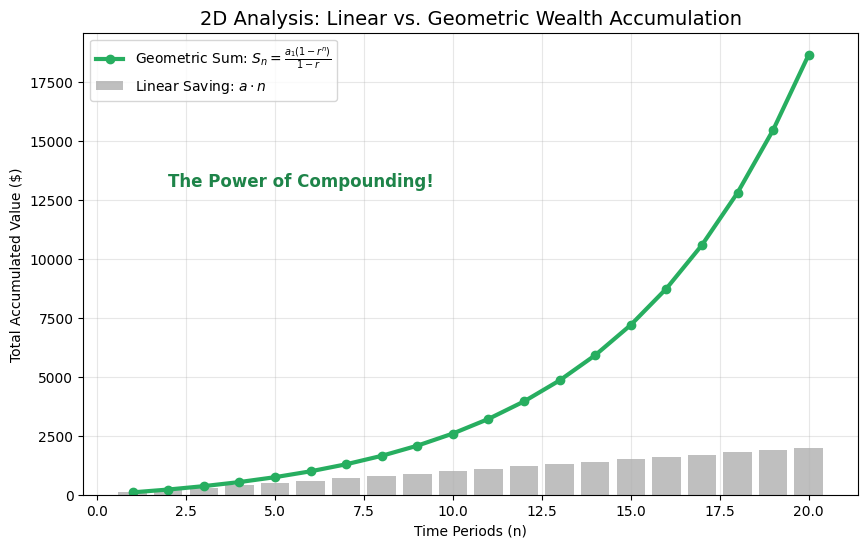

✅ 3D Asset saved: ../../../assets\65_series_3d.png


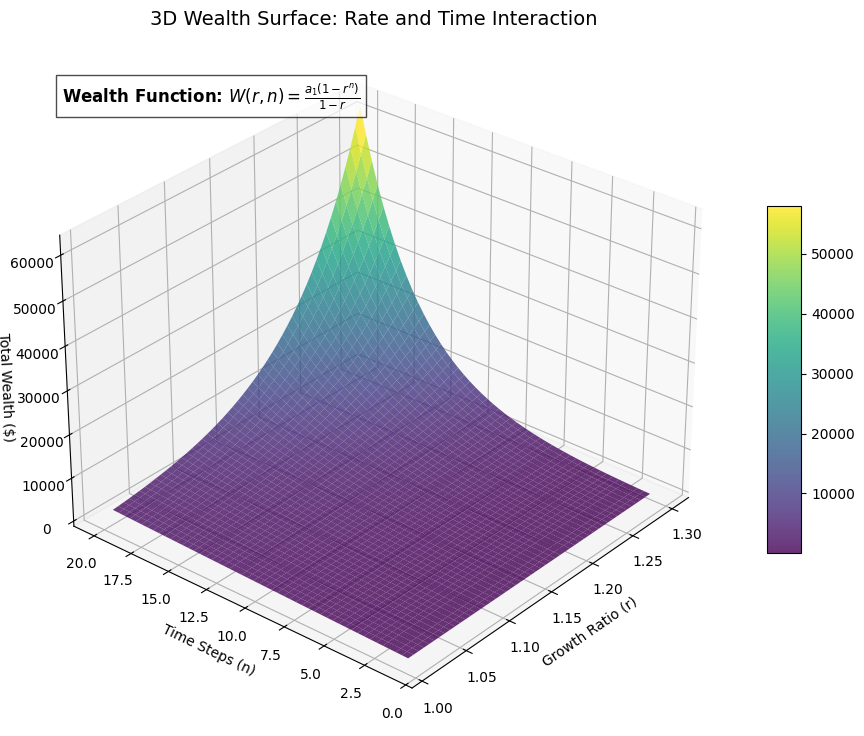

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import os
import warnings

# RuntimeWarning (0'a bölme) mesajlarını terminalde görmemek için (kod içinde zaten hallediyoruz)
warnings.filterwarnings("ignore", category=RuntimeWarning) 

def run_series_master():
    # --- PROFESSIONAL PATH SETUP ---
    asset_path = r'../../../assets'
    if not os.path.exists(asset_path): 
        os.makedirs(asset_path)

    # 1. Generate Series Data
    n_terms = 20
    a1 = 100 # Başlangıç miktarı
    r_const = 1.2  # %20 artış oranı
    
    steps = np.arange(1, n_terms + 1)
    
    # Geometrik Terimler ve Toplam
    terms_geo = a1 * (r_const**(steps - 1))
    sums_geo = a1 * (1 - r_const**steps) / (1 - r_const)
    
    # Lineer Karşılaştırma (Her adımda sadece 100 ekleme)
    sums_lin = a1 * steps

    # --- 📸 ASSET 1: 2D ACCUMULATION COMPARISON (65_series_2d.png) ---
    plt.figure(figsize=(10, 6))
    
    # RAW STRING (r"") kullanarak SyntaxWarning'i engelliyoruz
    plt.bar(steps, sums_lin, alpha=0.5, label=r'Linear Saving: $a \cdot n$', color='gray')
    plt.plot(steps, sums_geo, 'o-', color='#27ae60', lw=3, label=r'Geometric Sum: $S_n = \frac{a_1(1-r^n)}{1-r}$')
    
    plt.text(2, sums_geo[-1]*0.7, "The Power of Compounding!", fontsize=12, weight='bold', color='#1e8449')
    plt.title("2D Analysis: Linear vs. Geometric Wealth Accumulation", fontsize=14)
    plt.xlabel("Time Periods (n)"); plt.ylabel("Total Accumulated Value ($)")
    plt.grid(alpha=0.3)
    plt.legend()
    
    save_path_2d = os.path.join(asset_path, '65_series_2d.png')
    plt.savefig(save_path_2d, dpi=300)
    print(f"✅ 2D Asset saved: {save_path_2d}")
    plt.show()

    # --- 📸 ASSET 2: 3D WEALTH SURFACE (65_series_3d.png) ---
    fig = plt.figure(figsize=(12, 9))
    ax3d = fig.add_subplot(111, projection='3d')
    
    # R (Oran) ve N (Zaman) düzlemi
    r_vals = np.linspace(1.01, 1.3, 50) # 1.0 yerine 1.01'den başlatarak bölme hatasını kökten çözüyoruz
    n_vals = np.linspace(1, 20, 50)
    R, N = np.meshgrid(r_vals, n_vals)
    
    # Geometrik Toplam Fonksiyonu
    Z_wealth = a1 * (1 - R**N) / (1 - R)

    surf = ax3d.plot_surface(R, N, Z_wealth, cmap='viridis', alpha=0.8, edgecolor='none')
    
    # Formül Etiketi (Raw String)
    ax3d.text2D(0.05, 0.9, r"Wealth Function: $W(r, n) = \frac{a_1(1-r^n)}{1-r}$", 
                transform=ax3d.transAxes, fontsize=12, fontweight='bold', 
                bbox=dict(facecolor='white', alpha=0.7))

    ax3d.set_title("3D Wealth Surface: Rate and Time Interaction", fontsize=14)
    ax3d.set_xlabel("Growth Ratio (r)"); ax3d.set_ylabel("Time Steps (n)"); ax3d.set_zlabel("Total Wealth ($)")
    fig.colorbar(surf, ax=ax3d, shrink=0.5, aspect=10)
    
    ax3d.view_init(elev=30, azim=-140)
    
    save_path_3d = os.path.join(asset_path, '65_series_3d.png')
    plt.savefig(save_path_3d, dpi=300)
    print(f"✅ 3D Asset saved: {save_path_3d}")
    plt.show()

if __name__ == "__main__":
    run_series_master()